Analyze the scans preprocessing - how many scans were disqualified, why, manual classification and source 

In [4]:
import pandas as pd

In [5]:
combined_df = pd.read_pickle('/home/gaia/Projects/legacy_data/combined_gm_volumes.pkl')

# remove duplicates based on subject_id and session_id
scans = combined_df.drop_duplicates(subset=['subject_id', 'session_id'])

/tmp/ipykernel_79217/64300803.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  scans['source'] = scans['source'].astype(str)


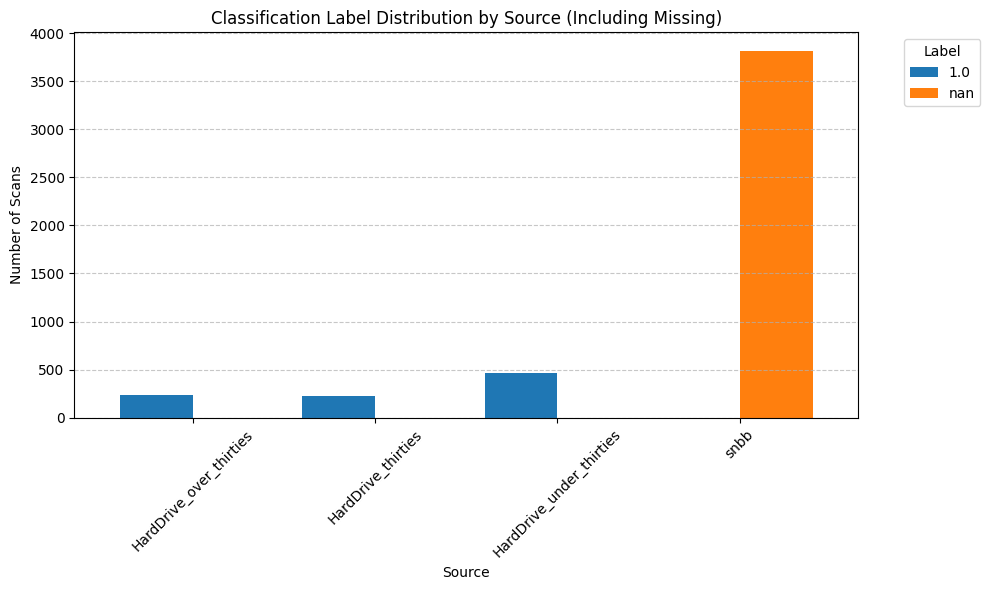

In [6]:
import matplotlib.pyplot as plt
import pandas as pd

# 1. Ensure 'source' is a string for clean grouping
scans['source'] = scans['source'].astype(str)

# 2. Create the counts including NaNs
# value_counts(dropna=False) ensures NaNs are counted as their own category
counts_df = (
    scans.groupby('source')['classification_label']
    .value_counts(dropna=False)
    .unstack(fill_value=0)
)

# 3. Rename the NaN column so it looks better on the legend
# It usually appears as np.nan or 'NaN'
counts_df = counts_df.rename(columns={pd.NA: 'Missing', float('nan'): 'Missing'})

# 4. Plot
ax = counts_df.plot(kind='bar', figsize=(10, 6), width=0.8)

plt.title('Classification Label Distribution by Source (Including Missing)')
plt.xlabel('Source')
plt.ylabel('Number of Scans')
plt.legend(title='Label', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()